# Movie & TV Show Recommendation System
## Notebook 1 — Data Preparation

**Project:** Content-Based Recommendation System  
**Dataset:** `netflix_titles.csv`  
**Output:** `netflix_titles_cleaned.csv`  

> Covers: 1.1 Data Understanding → 1.2 Data Clean → 1.3 EDA → 1.4 Data Preprocessing


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

DATA_PATH = 'netflix_titles.csv'


---
## 1.1 Data Understanding

### 1.1.1 Read Data
Load the dataset and preview the first rows.
**Why:** First look at column names, types, and typical values.

In [2]:
data = pd.read_csv(DATA_PATH)
df = data.copy()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 1.1.2 Random Sample Data
**Why:** Random samples reveal messy entries that might not appear in the first rows.

In [3]:
df.sample(10, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4970,s4971,Movie,"Game Over, Man!",Kyle Newacheck,"Adam DeVine, Anders Holm, Blake Anderson, Utka...",United States,"March 23, 2018",2018,TV-MA,102 min,"Action & Adventure, Comedies",Three buddies with big dreams go from underach...
3362,s3363,Movie,Arsenio Hall: Smart & Classy,Brian Volk-Weiss,Arsenio Hall,United States,"October 29, 2019",2019,TV-MA,63 min,Stand-Up Comedy,"In his first stand-up special, Arsenio Hall di..."
5494,s5495,TV Show,Kazoops!,NaN,"Reece Pockney, Scott Langley, Alex Babic, Gemm...",Australia,"May 5, 2017",2017,TV-Y,3 Seasons,Kids' TV,Music meets imagination in this inventive anim...
1688,s1689,TV Show,We Are the Champions,NaN,NaN,United States,"November 17, 2020",2020,TV-MA,1 Season,"Docuseries, Reality TV","Explore an array of unique competitions, from ..."
1349,s1350,TV Show,"Pablo Escobar, el patrón del mal",NaN,"Andrés Parra, Angie Cepeda, Cecilia Navia, Vic...",Colombia,"February 3, 2021",2012,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",From his days as a petty thief to becoming hea...
4862,s4863,TV Show,Saint Seiya: The Lost Canvas,NaN,"Tetsuya Kakihara, Hiro Shimono, Aya Hirano, At...",Japan,"May 15, 2018",2009,TV-MA,1 Season,"Anime Series, International TV Shows",This anime adventure follows the battle betwee...
2676,s2677,TV Show,Fauda,NaN,"Lior Raz, Hisham Suliman, Shadi Mar'i, Laëtiti...",Israel,"April 16, 2020",2020,TV-MA,3 Seasons,"Crime TV Shows, International TV Shows, TV Act...",A top Israeli agent comes out of retirement to...
487,s488,TV Show,The Cook of Castamar,NaN,"Michelle Jenner, Roberto Enríquez, Hugo Silva,...",NaN,"July 9, 2021",2021,TV-MA,1 Season,"International TV Shows, Romantic TV Shows, Spa...","In 1720 Madrid, a talented cook catches the ey..."
1671,s1672,Movie,The App That Stole Christmas,Monica Floyd,"Jackie Long, Diane Marie Howard, Jaylin Hall, ...",United States,"November 20, 2020",2020,TV-PG,64 min,"Children & Family Movies, Comedies",A tech entrepreneur's Christmas shopping app i...
5028,s5029,Movie,Mute,Duncan Jones,"Alexander Skarsgård, Paul Rudd, Justin Theroux","United Kingdom, Germany","February 23, 2018",2018,TV-MA,127 min,"Sci-Fi & Fantasy, Thrillers","When his girlfriend vanishes, a mute man ventu..."


### 1.1.3 Size of Data
**Why:** Dataset size determines EDA scope and preprocessing cost.

In [4]:
print('Rows, Columns:', df.shape)

Rows, Columns: (8807, 12)


### 1.1.4 Information of Data
**Why:** `info()` gives a structural overview; missing counts show which columns need cleaning.

In [5]:
df.info()
missing = df.isna().sum().sort_values(ascending=False)
print('\nMissing values per column:\n')
display(missing)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing values per column:



director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### 1.1.5 Check Names of Columns
**Why:** Verify exact names before standardizing them.

In [6]:
print('Columns:')
for c in df.columns:
    print('-', c)

Columns:
- show_id
- type
- title
- director
- cast
- country
- date_added
- release_year
- rating
- duration
- listed_in
- description


### 1.1.6 Check Description
**Why:** Numeric stats reveal unusual ranges; categorical top-values show catalog composition.

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', num_cols)
if num_cols:
    display(df[num_cols].describe().T)
else:
    print('No numeric columns at this stage.')

cat_cols = [c for c in df.columns if c not in num_cols]
for c in cat_cols[:5]:
    print(f'\n{c} top 5:')
    print(df[c].value_counts().head(5).to_string())


Numeric columns: ['release_year']


,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0



show_id top 5:
show_id
s1       1
s5875    1
s5869    1
s5870    1
s5871    1

type top 5:
type
Movie      6131
TV Show    2676

title top 5:
title
Dick Johnson Is Dead                1
Ip Man 2                            1
Hannibal Buress: Comedy Camisado    1
Turbo FAST                          1
Masha's Tales                       1

director top 5:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14

cast top 5:
cast
David Attenborough                                                                         19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil    14
Samuel West                                                                                10
Jeff Dunham                                                                                 7
David Spade, London Hughes, Fortune Feimster                                                6


### 1.1.7 Number of Unique Values per Column
**Why:** High-unique = identifiers; low-unique = categorical features.

In [8]:
unique_counts = df.nunique(dropna=True).sort_values(ascending=False)
display(unique_counts)

show_id         8807
title           8807
description     8775
cast            7692
director        4528
date_added      1767
country          748
listed_in        514
duration         220
release_year      74
rating            17
type               2
dtype: int64

### 1.1.8 Check Balance of Data
For a recommendation system there is no target label. 'Balance' means distribution of key catalog dimensions: content type, rating, release decade.
**Why:** Knowing that Movies outnumber TV Shows (or that most content is recent) informs how we build and evaluate recommendations.


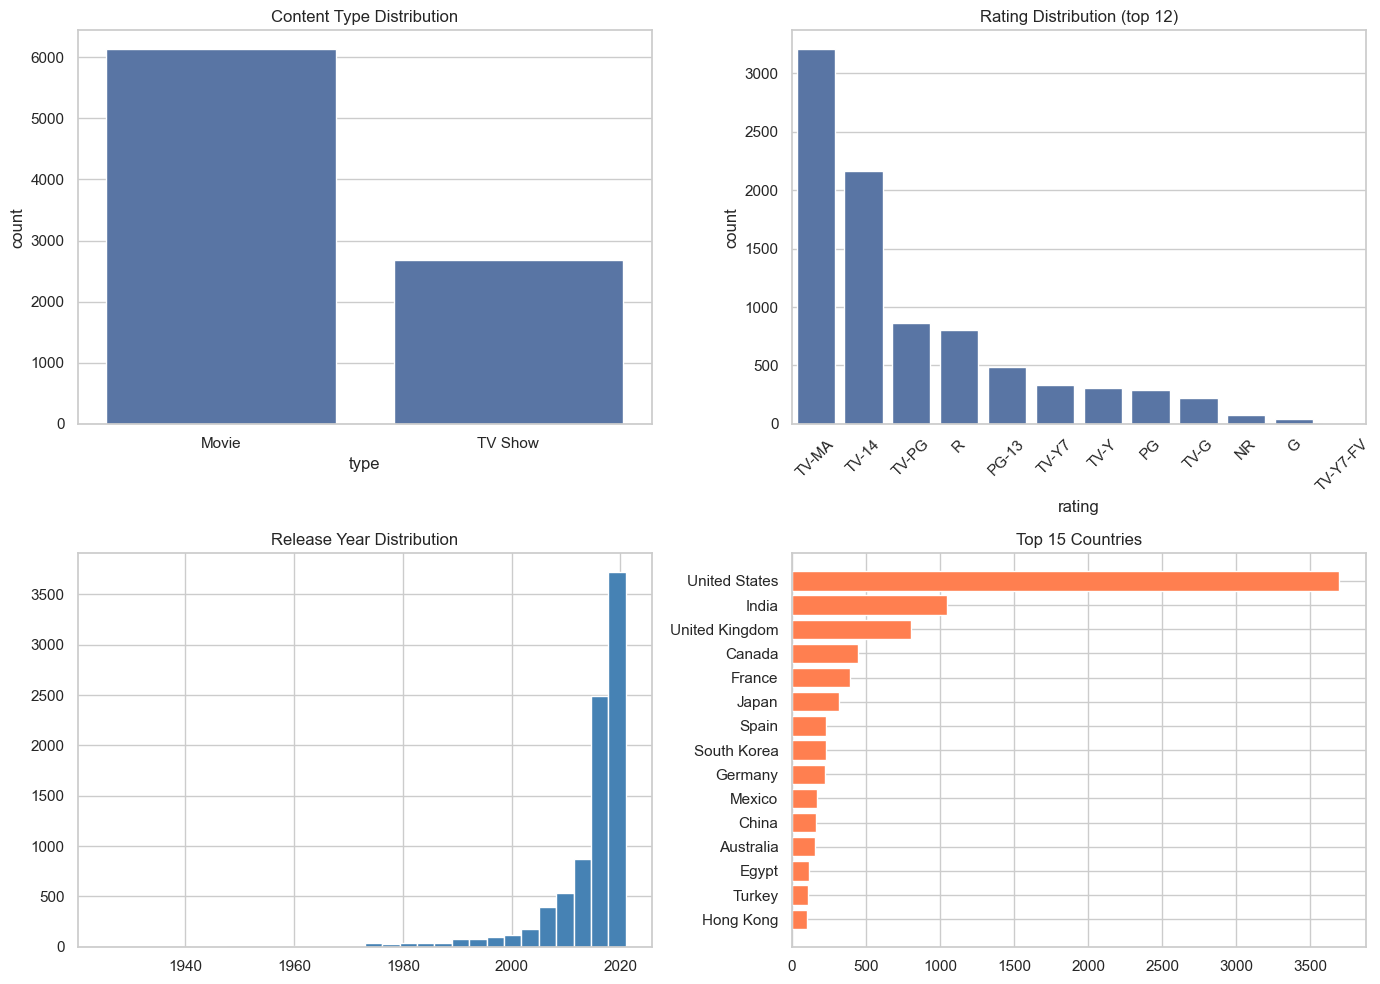

Type distribution:
type
Movie      69.6%
TV Show    30.4%


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='type', order=df['type'].value_counts().index, ax=axes[0,0])
axes[0,0].set_title('Content Type Distribution')

top_ratings = df['rating'].value_counts().head(12).index
sub_r = df[df['rating'].isin(top_ratings)]
sns.countplot(data=sub_r, x='rating', order=top_ratings, ax=axes[0,1])
axes[0,1].set_title('Rating Distribution (top 12)')
axes[0,1].tick_params(axis='x', rotation=45)

df['release_year'].dropna().astype(int).hist(bins=30, ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Release Year Distribution')

top_countries = df['country'].dropna().str.split(',').explode().str.strip().value_counts().head(15)
axes[1,1].barh(top_countries.index[::-1], top_countries.values[::-1], color='coral')
axes[1,1].set_title('Top 15 Countries')

plt.tight_layout()
plt.show()

print('Type distribution:')
print(df['type'].value_counts(normalize=True).map('{:.1%}'.format).to_string())


---
## 1.2 Data Clean

### 1.2.1 Remove Duplicate Rows
**Why:** Duplicates inflate counts and distort distribution insights.

In [10]:
dup_count = df.duplicated().sum()
print('Duplicate rows:', dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print('New shape:', df.shape)


Duplicate rows: 0
New shape: (8807, 12)


### 1.2.2 Fix Column Names
Standardize to lowercase with underscores.
**Why:** Consistent names reduce KeyError bugs.

In [11]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_', regex=False)
)
print(df.columns.tolist())


['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


### 1.2.3 Correct Data Types
**Why:** Correct types enable proper sorting, filtering, and text processing.

In [12]:
text_cols = ['show_id','type','title','director','cast','country','rating','duration','listed_in','description']
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].astype('string')

if 'date_added' in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

if 'release_year' in df.columns:
    df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

df.dtypes


show_id         string[python]
type            string[python]
title           string[python]
director        string[python]
cast            string[python]
country         string[python]
date_added      datetime64[ns]
release_year             int64
rating          string[python]
duration        string[python]
listed_in       string[python]
description     string[python]
dtype: object

### 1.2.4 Handle Missing Values
**Strategy:**
- `title`, `type` → drop row (can't recommend without these)
- `release_year` → fill with median (keeps the item)
- All other text fields → fill with `'unknown'` so text similarity still works

**Why:** Dropping everything with any missing value would lose ~30% of the catalog.


In [13]:
display(df.isna().sum().sort_values(ascending=False))

before = df.shape[0]
df = df.dropna(subset=['title','type']).reset_index(drop=True)
print('Dropped', before - df.shape[0], 'rows missing title/type')

if df['release_year'].isna().any():
    fill_year = int(df['release_year'].median())
    df['release_year'] = df['release_year'].fillna(fill_year)
    print('Filled missing release_year with median:', fill_year)

fill_text = ['director','cast','country','rating','duration','listed_in','description']
for c in fill_text:
    if c in df.columns:
        df[c] = df[c].fillna('unknown')

print('\nMissing values after handling:')
display(df.isna().sum().sort_values(ascending=False))


director        2634
country          831
cast             825
date_added        98
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

Dropped 0 rows missing title/type

Missing values after handling:


date_added      98
show_id          0
type             0
title            0
director         0
cast             0
country          0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

### 1.2.5 Remove Invalid Values
**Why:** Invalid entries corrupt duration stats and can produce nonsense recommendations.

In [14]:
valid_types = {'Movie','TV Show'}
df['type'] = df['type'].str.strip()
before = df.shape[0]
df = df[df['type'].isin(valid_types)].reset_index(drop=True)
print('Removed', before - df.shape[0], 'rows with invalid type')

current_year = pd.Timestamp.today().year
before = df.shape[0]
df = df[(df['release_year'] >= 1900) & (df['release_year'] <= current_year)].reset_index(drop=True)
print('Removed', before - df.shape[0], 'rows with unrealistic release_year')

duration_num = df['duration'].str.extract(r'(\d+)')[0]
print('Rows with non-parseable duration:', duration_num.isna().sum())
df = df[duration_num.notna()].reset_index(drop=True)
print('New shape:', df.shape)


Removed 0 rows with invalid type
Removed 0 rows with unrealistic release_year
Rows with non-parseable duration: 3
New shape: (8804, 12)


### 1.2.6 Standardize Categorical Values
**Why:** Without standardization, 'TV Show' and ' tv show' would be treated as different categories.

In [15]:
df['type'] = df['type'].str.strip()
df['rating'] = df['rating'].str.strip().str.upper()

df['genres'] = (
    df['listed_in'].fillna('unknown')
      .str.split(',')
      .apply(lambda xs: [x.strip() for x in xs if str(x).strip() != ''])
)

df['countries'] = (
    df['country'].fillna('unknown')
      .str.split(',')
      .apply(lambda xs: [x.strip() for x in xs if str(x).strip() != ''])
)
df['primary_country'] = df['countries'].apply(
    lambda xs: xs[0] if isinstance(xs, list) and len(xs) > 0 else 'unknown'
)

df[['type','rating','listed_in','genres','primary_country']].head()


,type,rating,listed_in,genres,primary_country
0,Movie,PG-13,Documentaries,[Documentaries],United States
1,TV Show,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Mysteries]",South Africa
2,TV Show,TV-MA,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac...",unknown
3,TV Show,TV-MA,"Docuseries, Reality TV","[Docuseries, Reality TV]",unknown
4,TV Show,TV-MA,"International TV Shows, Romantic TV Shows, TV ...","[International TV Shows, Romantic TV Shows, TV...",India


### 1.2.7 Fix Inconsistent Units — Duration
`duration` mixes **minutes** (Movies) and **seasons** (TV Shows).
**Why:** Mixing units makes any numeric comparison meaningless. We split into `duration_value` and `duration_unit`.


In [16]:
df['duration_value'] = pd.to_numeric(
    df['duration'].str.extract(r'(\d+)')[0], errors='coerce'
)
df['duration_unit'] = np.where(
    df['duration'].str.contains('min', case=False, na=False), 'min',
    np.where(df['duration'].str.contains('season', case=False, na=False), 'season', 'unknown')
)

display(pd.crosstab(df['type'], df['duration_unit']))
df[['type','duration','duration_value','duration_unit']].head()


duration_unit,min,season
type,,
Movie,6128,0
TV Show,0,2676


,type,duration,duration_value,duration_unit
0,Movie,90 min,90,min
1,TV Show,2 Seasons,2,season
2,TV Show,1 Season,1,season
3,TV Show,1 Season,1,season
4,TV Show,2 Seasons,2,season


### 1.2.8 Outlier Flagging (IQR Method)
Flag outliers in `release_year` and `duration_value`.
**Why:** In a content catalog, outliers are valid but rare items — we flag, not remove. The flag is used in 1.4.3 for optional capping.


In [17]:
def iqr_bounds(series):
    s = series.dropna().astype(float)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for col in ['release_year', 'duration_value']:
    lo, hi = iqr_bounds(df[col])
    df[f'{col}_outlier_iqr'] = (df[col] < lo) | (df[col] > hi)
    n = df[f'{col}_outlier_iqr'].sum()
    print(f'{col}: bounds=({lo:.1f}, {hi:.1f}) | flagged = {n}')

df[['release_year','release_year_outlier_iqr','duration_value','duration_value_outlier_iqr']].head()


release_year: bounds=(2004.0, 2028.0) | flagged = 719
duration_value: bounds=(-154.0, 262.0) | flagged = 2


,release_year,release_year_outlier_iqr,duration_value,duration_value_outlier_iqr
0,2020,False,90,False
1,2021,False,2,False
2,2021,False,1,False
3,2021,False,1,False
4,2021,False,2,False


---
## 1.3 EDA

### 1.3.1 Univariate Analysis
#### 1.3.1.1 Distribution of Numerical Features
**Why:** Reveals data range, central tendency, and skew before modeling.

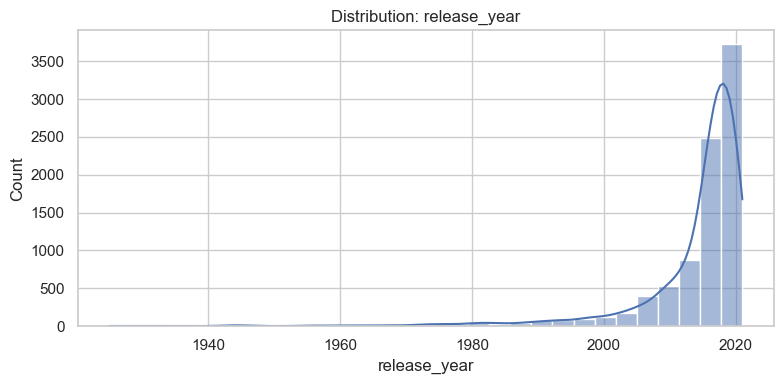

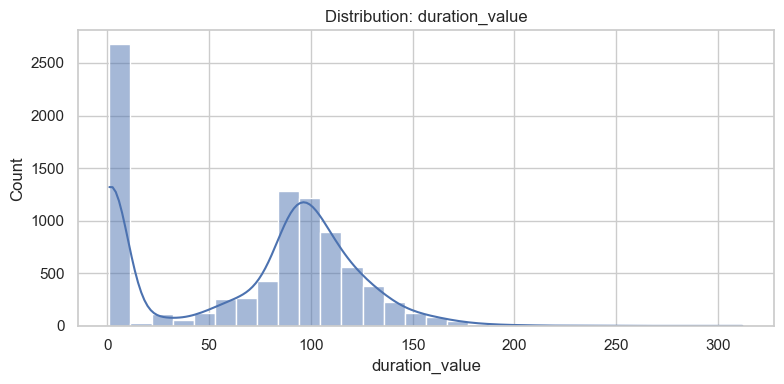

In [18]:
num_eda_cols = [c for c in ['release_year','duration_value'] if c in df.columns]

for col in num_eda_cols:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()


#### 1.3.1.2 Count Plots for Categorical Features
**Why:** Shows catalog composition and long-tail effects critical for recommendation design.

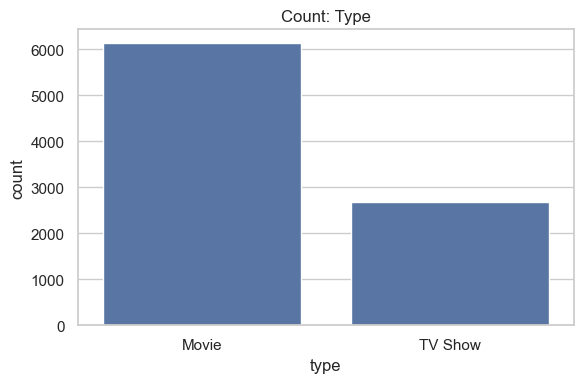

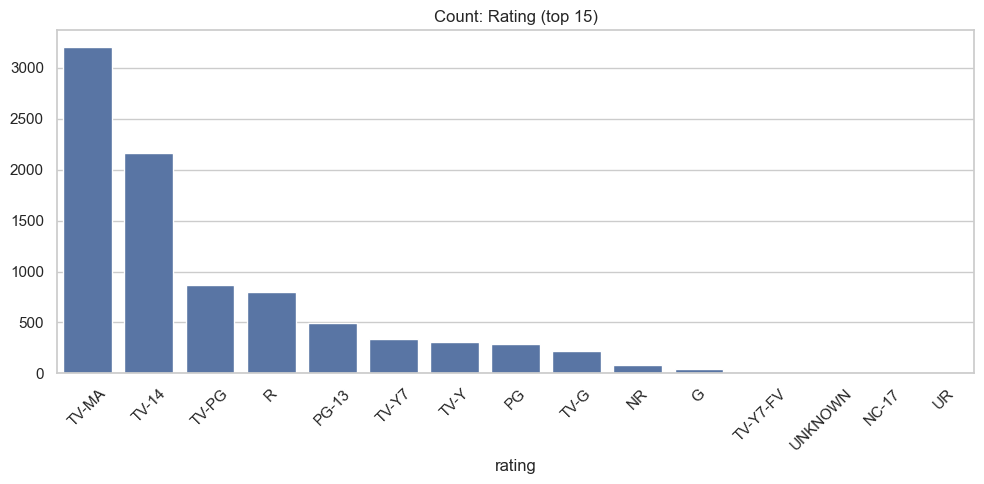

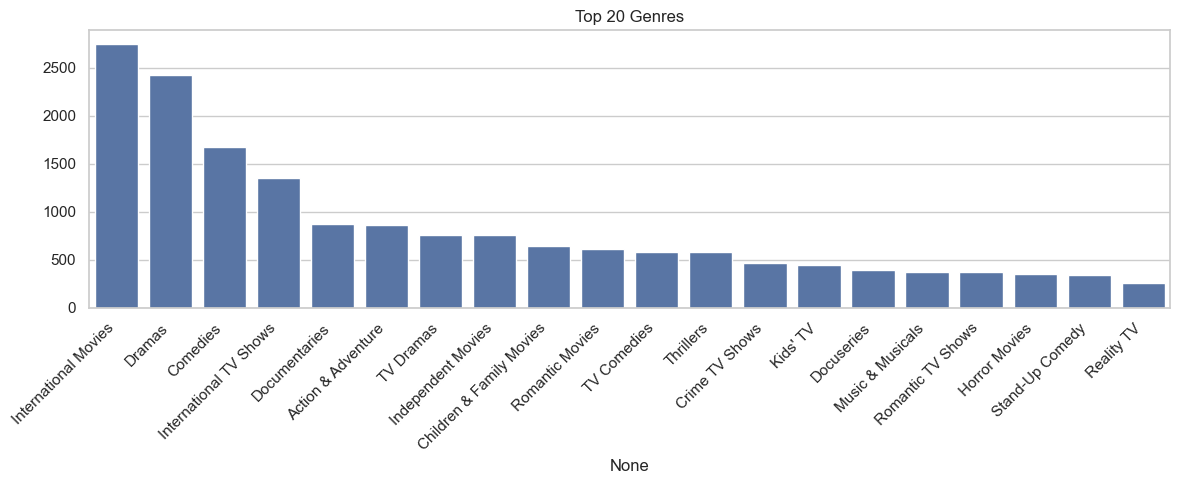

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title('Count: Type')
plt.tight_layout(); plt.show()

top_ratings = df['rating'].value_counts().head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=top_ratings.index, y=top_ratings.values)
plt.title('Count: Rating (top 15)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

genre_counts = pd.Series([g for gs in df['genres'] for g in gs if g]).value_counts()
plt.figure(figsize=(12,5))
sns.barplot(x=genre_counts.head(20).index, y=genre_counts.head(20).values)
plt.title('Top 20 Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


#### 1.3.1.3 Skewness and Kurtosis
**Why:** Summarizes distribution shape — helps decide whether log transforms are needed.

In [20]:
stats = []
for col in num_eda_cols:
    s = df[col].dropna().astype(float)
    stats.append({'feature': col, 'skewness': round(s.skew(),3),
                  'kurtosis': round(s.kurtosis(),3), 'min': s.min(), 'max': s.max()})
display(pd.DataFrame(stats))


,feature,skewness,kurtosis,min,max
0,release_year,-3.446,16.227,1925.0,2021.0
1,duration_value,-0.190,-1.082,1.0,312.0


#### 1.3.1.4 Log Transformation for Skewed Features
Apply only to `duration_value` if |skew| > 1. `release_year` is NOT log-transformed (calendar value, not count).
**Why:** Log reduces influence of extreme durations on numeric similarity.

In [21]:
for col in ['duration_value']:
    s = df[col].dropna().astype(float)
    if (s > 0).all() and abs(s.skew()) > 1:
        df[f'log1p_{col}'] = np.log1p(df[col].astype(float))
        print(f'Created log1p_{col} — original skew: {s.skew():.2f}')
        fig, axes = plt.subplots(1, 2, figsize=(12,4))
        sns.histplot(s, bins=30, kde=True, ax=axes[0])
        axes[0].set_title(f'Original: {col}')
        sns.histplot(df[f'log1p_{col}'].dropna(), bins=30, kde=True, ax=axes[1])
        axes[1].set_title(f'Log1p: {col}')
        plt.tight_layout(); plt.show()
    else:
        print(f'{col} skew={s.skew():.2f} — log transform not applied')


duration_value skew=-0.19 — log transform not applied


### 1.3.2 Bivariate Analysis
#### 1.3.2.1 Correlation Matrix Heatmap
**Why:** Shows linear relationships between numeric features. Expected to be weak here.

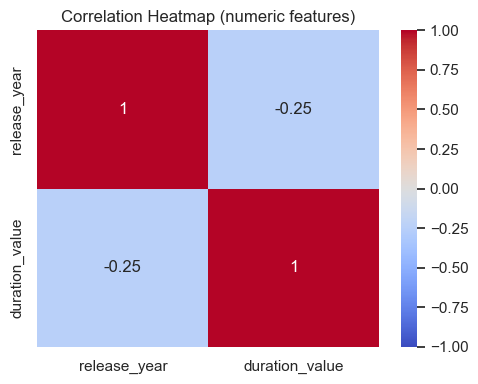

In [22]:
corr_candidates = [c for c in ['release_year','duration_value'] if c in df.columns]
if len(corr_candidates) >= 2:
    corr = df[corr_candidates].corr()
    plt.figure(figsize=(5,4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Heatmap (numeric features)')
    plt.tight_layout(); plt.show()


#### 1.3.2.2 Scatter Plots
**Why:** Reveals patterns like whether newer Movies tend to be longer.

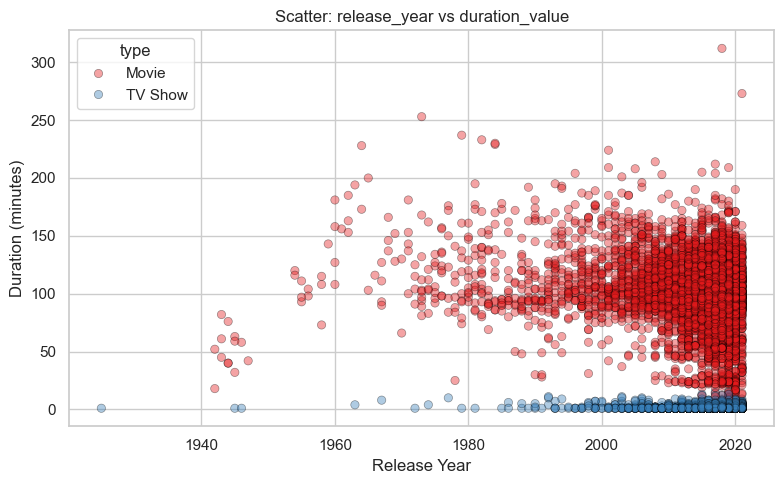

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='release_year', y='duration_value', hue='type', alpha=0.4, palette='Set1', edgecolor='black')
plt.title('Scatter: release_year vs duration_value')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')

plt.tight_layout(); plt.show()


#### 1.3.2.3 Boxplot — Categorical vs Numerical
**Why:** `release_year` is comparable across both types. Reveals whether Movies and TV Shows differ in age distribution.

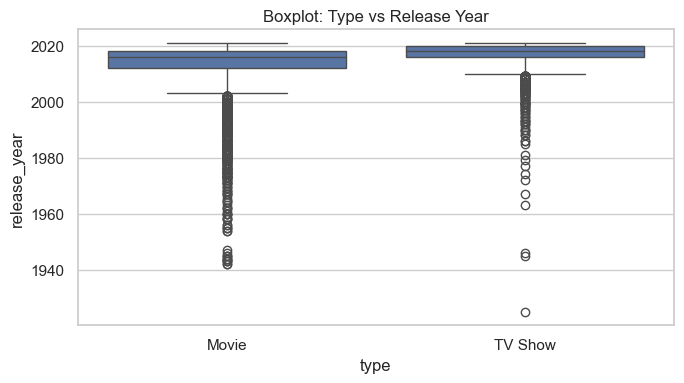

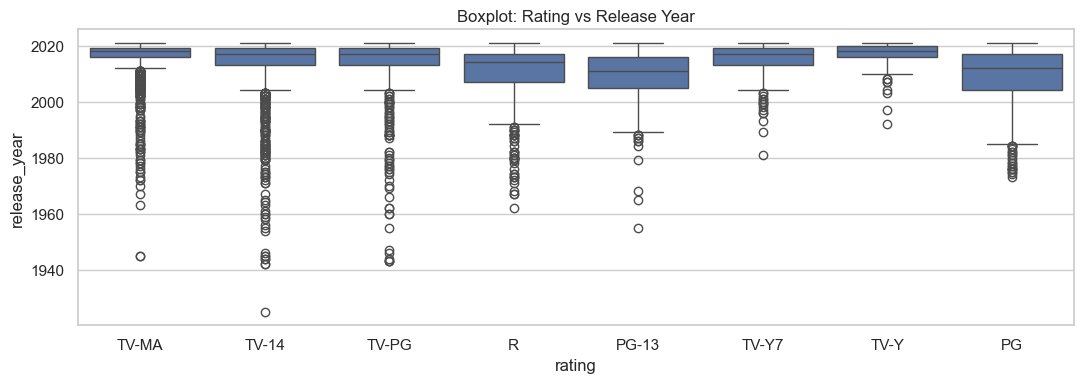

In [24]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='type', y='release_year')
plt.title('Boxplot: Type vs Release Year')
plt.tight_layout(); plt.show()

top_rating_labels = df['rating'].value_counts().head(8).index
sub = df[df['rating'].isin(top_rating_labels)]
plt.figure(figsize=(11,4))
sns.boxplot(data=sub, x='rating', y='release_year', order=top_rating_labels)
plt.title('Boxplot: Rating vs Release Year')
plt.tight_layout(); plt.show()


#### 1.3.2.4 Barplot — Average Duration by Type
**Recommendation adaptation:** No target variable exists — we show average duration per type.
**Why:** Confirms the unit split was necessary (Movies=minutes, TV Shows=seasons have very different scales).


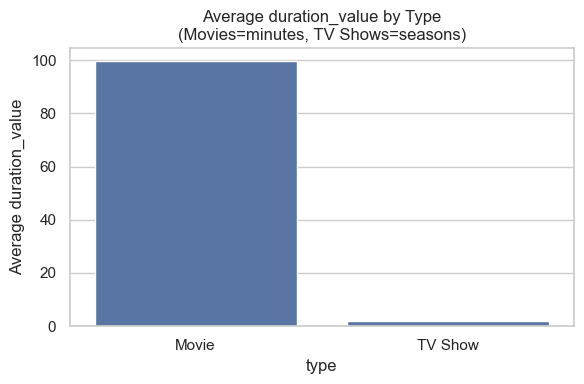

In [25]:
avg_dur = df.groupby('type')['duration_value'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=avg_dur.index, y=avg_dur.values)
plt.title('Average duration_value by Type\n(Movies=minutes, TV Shows=seasons)')
plt.ylabel('Average duration_value')
plt.tight_layout(); plt.show()


#### 1.3.2.5 Barplot — Top Genres by Content Type
**Recommendation adaptation:** Shows genre breakdown by type.
**Why:** Understanding whether genres skew toward Movies or TV Shows is critical for retrieving contextually similar content.


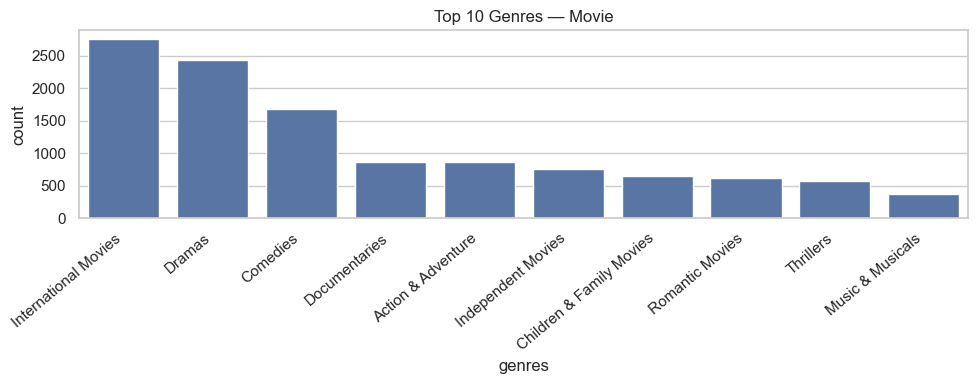

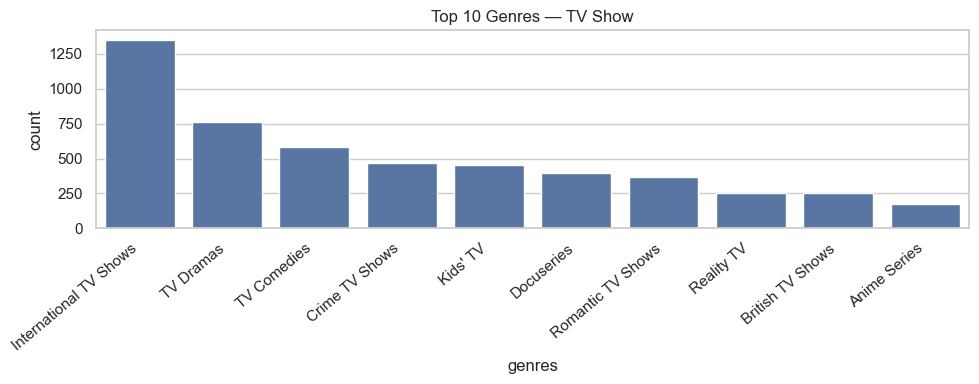

In [26]:
tmp = df[['type','genres']].explode('genres')
tmp = tmp[tmp['genres'].notna() & (tmp['genres'] != '')]
counts = (
    tmp.groupby(['type','genres']).size()
       .reset_index(name='count')
       .sort_values(['type','count'], ascending=[True,False])
)
for t in df['type'].value_counts().index:
    sub = counts[counts['type'] == t].head(10)
    plt.figure(figsize=(10,4))
    sns.barplot(data=sub, x='genres', y='count')
    plt.title(f'Top 10 Genres — {t}')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout(); plt.show()


---
## 1.4 Data Preprocessing

### 1.4.1 Encoding Categorical Variables
For a **content-based recommendation system**, text columns are NOT one-hot encoded — they are kept as text for TF-IDF in the model notebook.
We encode only `type` (binary, safe) and build a `content_profile` text field.
**Why:** One-hot encoding `cast` or `description` produces an unmanageable sparse matrix. TF-IDF handles this naturally.


In [27]:
# Binary encode type
type_dummies = pd.get_dummies(df['type'], prefix='type')
print('Type dummy columns:', type_dummies.columns.tolist())
display(type_dummies.head(3))


Type dummy columns: ['type_Movie', 'type_TV Show']


,type_Movie,type_TV Show
0,True,False
1,False,True
2,False,True


### 1.4.3 Outlier Detection & Treatment
Outliers were flagged in 1.2.8. Here we decide treatment:
- **Keep** all catalog items (rare films are still valid recommendations)
- **Cap** `duration_value` for numeric stability in hybrid scores
**Why:** Removing items from a recommendation catalog is almost always wrong.


In [28]:
cap_col = 'duration_value'
q1, q3 = df[cap_col].quantile(0.25), df[cap_col].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr

df['duration_value_capped'] = df[cap_col].clip(lower=lo, upper=hi)

print(f'IQR bounds for {cap_col}: ({lo:.1f}, {hi:.1f})')
print(f'Items outside bounds: {df[cap_col+"_outlier_iqr"].sum()} (flagged, not removed)')
df[['duration_value','duration_value_capped']].head()


IQR bounds for duration_value: (-154.0, 262.0)
Items outside bounds: 2 (flagged, not removed)


,duration_value,duration_value_capped
0,90,90
1,2,2
2,1,1
3,1,1
4,2,2


### Save Cleaned Dataset
Save **one** cleaned file. Notebook 2 reads from this directly — no encoded file needed.

In [29]:
CLEAN_PATH = 'netflix_titles_cleaned.csv'
df.to_csv(CLEAN_PATH, index=False)
print(f'Saved cleaned data to: {CLEAN_PATH}')
print(f'Shape: {df.shape}')


Saved cleaned data to: netflix_titles_cleaned.csv
Shape: (8804, 20)
